---
## 1. 데이터 불러오기

### 💡 왜 필요한가?
CMAPSS 데이터는 컬럼명이 없는 txt 파일이라  
직접 컬럼명을 지정해서 불러와야 합니다.

| 컬럼 | 의미 |
|------|------|
| unit_nr | 엔진 번호 |
| time_cycles | 비행 횟수 |
| setting_1~3 | 운전 조건 |
| s_1~s_21 | 센서 측정값 21개 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 컬럼명 정의
col_names = ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3',
             's_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9',
             's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_16', 's_17',
             's_18', 's_19', 's_20', 's_21']

# train 데이터 불러오기
train_FD001 = pd.read_csv('train_FD001.txt', sep=r'\s+', header=None, names=col_names)

#sep=r'\s+' → 공백으로 구분된 파일이라는 뜻. 앞에 r을 붙이면 "이 문자열은 그냥 글자 그대로 읽어줘" 라는 뜻. 그래서 \s를 특수문자가 아닌 말 그대로 \s 로 인식
#header=None → 원본 파일에 컬럼명이 없어서 직접 지정
#names=col_names → 위에서 정의한 컬럼명 붙여주기

# 확인
train_FD001.head()

,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


---
## 2. 데이터 기본 파악

### 💡 왜 필요한가?
데이터를 처음 받으면 무작정 전처리하면 안됩니다.  
먼저 데이터가 어떻게 생겼는지 파악해야  
어떤 전처리가 필요한지 판단할 수 있습니다.

| 확인 항목 | 왜 확인하나? |
|----------|------------|
| shape | 행/열 개수 파악 |
| info | 데이터 타입, 결측값 확인 |
| describe | 각 컬럼의 통계값 확인 |
| 엔진 수 | 총 몇 개 엔진인지 |
| 엔진별 수명 | 각 엔진이 몇 번 비행했는지 |

In [2]:
# 데이터 크기 확인
print('shape:', train_FD001.shape)


shape: (20631, 26)


총 20,631행 (데이터 포인트)

26개 컬럼 (unit_nr, time_cycles, setting 3개, 센서 21개)

In [3]:
# 데이터 타입 및 결측값 확인
print('\n--- info ---')
train_FD001.info()



--- info ---
<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   unit_nr      20631 non-null  int64  
 1   time_cycles  20631 non-null  int64  
 2   setting_1    20631 non-null  float64
 3   setting_2    20631 non-null  float64
 4   setting_3    20631 non-null  float64
 5   s_1          20631 non-null  float64
 6   s_2          20631 non-null  float64
 7   s_3          20631 non-null  float64
 8   s_4          20631 non-null  float64
 9   s_5          20631 non-null  float64
 10  s_6          20631 non-null  float64
 11  s_7          20631 non-null  float64
 12  s_8          20631 non-null  float64
 13  s_9          20631 non-null  float64
 14  s_10         20631 non-null  float64
 15  s_11         20631 non-null  float64
 16  s_12         20631 non-null  float64
 17  s_13         20631 non-null  float64
 18  s_14         20631 non-null  float64
 19  s

모든 컬럼이 20631 non-null → 결측값 없음

unit_nr, time_cycles → 정수(int64)

나머지 센서값들 → 실수(float64)

메모리 4.1MB → 가벼운 데이터

In [4]:
# 기초 통계
print('\n--- 기초 통계 ---')
train_FD001.describe()


--- 기초 통계 ---


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,...,0.737553,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


unit_nr max=100 → 엔진이 총 100개

time_cycles max=362 → 가장 오래 산 엔진이 362번 비행

setting_3 std=0.0 → 값이 전혀 안 변함 → 상수 센서 제거 대상

s_1 min=max=518.67, std=0.0 → 얘도 상수 → 제거 대상

s_5 std≈0 → 얘도 거의 상수 → 제거 대상

---
### 📊 기본 파악 결과 요약

| 항목 | 결과 | 의미 |
|------|------|------|
| 총 데이터 수 | 20,631행 | -  |
| 컬럼 수 | 26개 | unit_nr, time_cycles, setting 3개, 센서 21개 |
| 결측값 | 없음 | 별도 결측값 처리 불필요 |
| 엔진 수 | 100개 | unit_nr max=100 |
| 최대 비행 횟수 | 362번 | time_cycles max=362 |
| 상수 센서 의심 | setting_3, s_1, s_5 | std=0 또는 min=max |

> ⚠️ setting_3, s_1, s_5는 std=0으로 값이 변하지 않음  
> → 다음 단계에서 시각화로 확인 후 제거 여부 결정

---
## 3. 엔진 수명 분석

### 💡 왜 필요한가?
엔진마다 총 비행 횟수(수명)가 다릅니다.  
이 분포를 보면 RUL 예측 범위를 이해할 수 있습니다.

| 확인 항목 | 왜 확인하나? |
|----------|------------|
| 엔진별 최대 cycle | 각 엔진이 몇 번 비행했는지 |
| 수명 분포 히스토그램 | 수명이 골고루 분포하는지 |

In [5]:
# 엔진별 최대 사이클 (수명) 확인
engine_life = train_FD001.groupby('unit_nr')['time_cycles'].max()
print(engine_life.describe())

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: time_cycles, dtype: float64


In [6]:
engine_life

unit_nr
1      192
2      287
3      179
4      189
5      269
      ... 
96     336
97     202
98     156
99     185
100    200
Name: time_cycles, Length: 100, dtype: int64

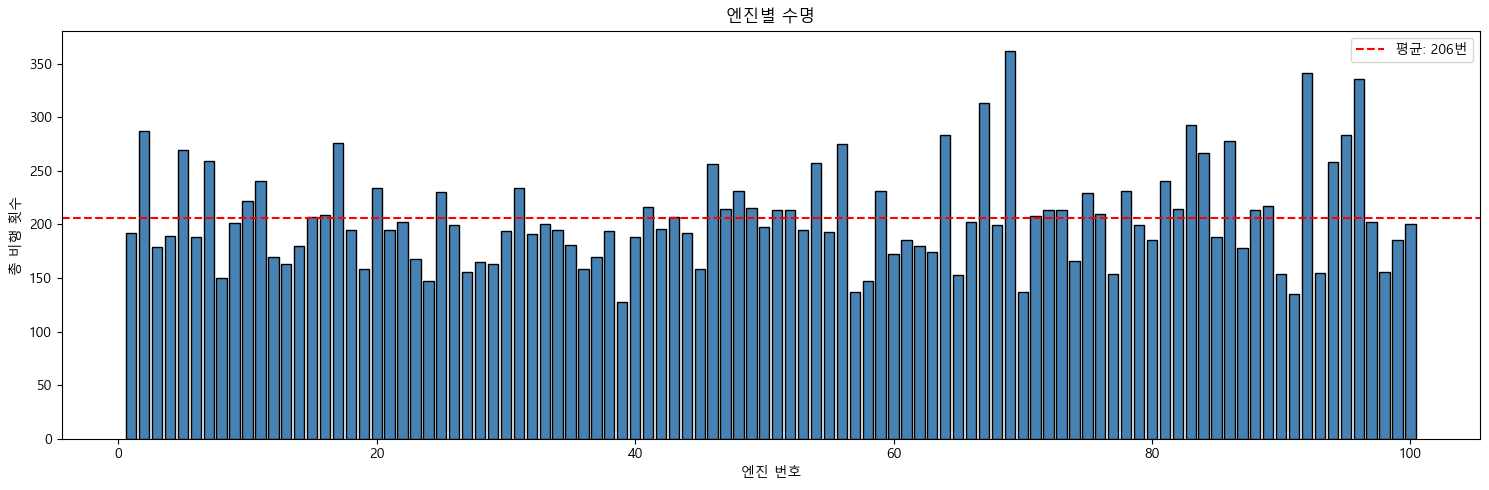

In [8]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(15, 5))
plt.bar(engine_life.index, engine_life.values, color='steelblue', edgecolor='black')
plt.xlabel('엔진 번호')
plt.ylabel('총 비행 횟수')
plt.title('엔진별 수명')
plt.axhline(y=engine_life.mean(), color='red', linestyle='--', label=f'평균: {engine_life.mean():.0f}번')
plt.legend()
plt.tight_layout()
plt.show()

---
### 📊 엔진 수명 분석 결과

| 항목 | 값 | 의미 |
|------|-----|------|
| 엔진 수 | 100개 | unit_nr 1~100 |
| 평균 수명 | 206번 | 평균 206번 비행 후 고장 |
| 최단 수명 | 128번 | 가장 빨리 고장난 엔진 |
| 최장 수명 | 362번 | 가장 오래 버틴 엔진 |
| 중앙값 | 199번 | 절반의 엔진이 199번 이내 고장 |

> 💡 대부분의 엔진이 150~250번 사이에 고장남
> 특이하게 오래 버티는 엔진(300번 이상)도 일부 존재

---
### 🔑 시계열 데이터 핵심 개념 정리

**Q. 엔진이 100개인데 왜 행이 20,000개 이상인가?**

> 엔진 1개당 **매 비행마다 1행씩** 기록되기 때문!

**Q. 한 행에는 어떤 정보가 있나?**

> **"엔진 N번이 M번째 비행을 했을 때 21개 센서가 측정한 값"**

| 컬럼 | 의미 |
|------|------|
| unit_nr | 엔진 번호 (1~100) |
| time_cycles | 몇 번째 비행인지 |
| s_1 ~ s_21 | 그 비행에서 측정된 센서값 21개 |

**Q. 센서 21개란?**
> 엔진에 붙어있는 온도, 압력, 속도 등 **21가지 측정 장치**  
> 매 비행마다 21개 센서가 동시에 값을 기록함

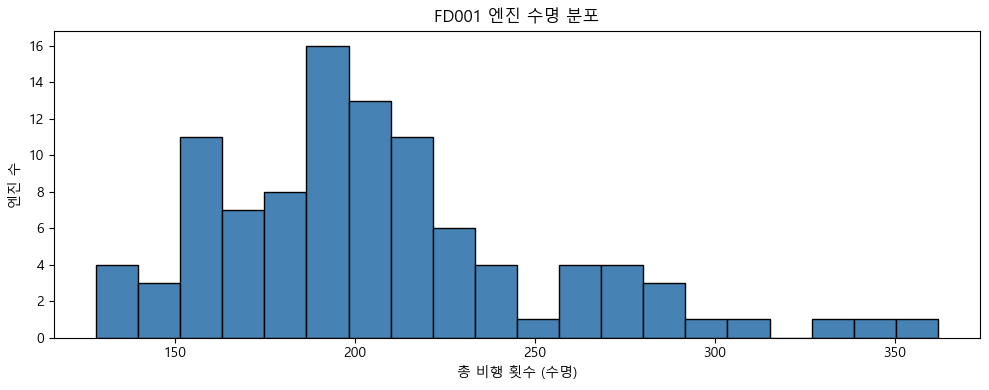

In [9]:
import matplotlib.pyplot as plt
import platform

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(10, 4))
plt.hist(engine_life, bins=20, color='steelblue', edgecolor='black')
plt.xlabel('총 비행 횟수 (수명)')
plt.ylabel('엔진 수')
plt.title('FD001 엔진 수명 분포')
plt.tight_layout()
plt.show()

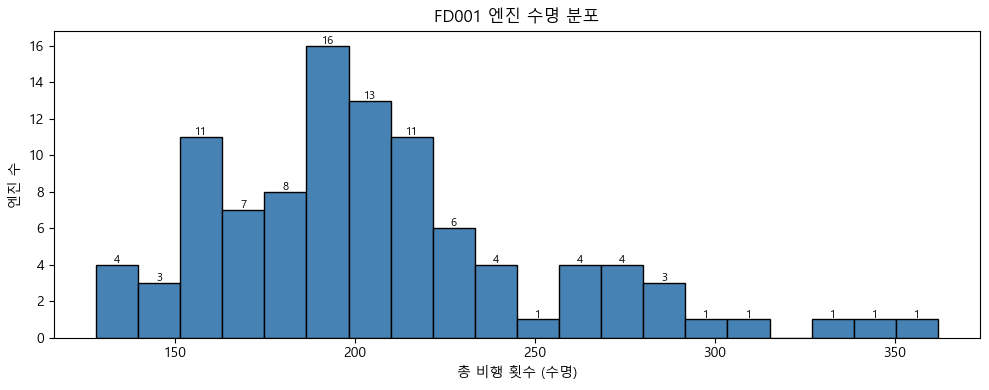

In [10]:
plt.figure(figsize=(10, 4))
bars = plt.hist(engine_life, bins=20, color='steelblue', edgecolor='black')

# 막대 위에 엔진 수 표시
for i in range(len(bars[0])):
    if bars[0][i] > 0:
        plt.text(bars[1][i] + (bars[1][1]-bars[1][0])/2, 
                 bars[0][i] + 0.1, 
                 str(int(bars[0][i])), 
                 ha='center', fontsize=8)

plt.xlabel('총 비행 횟수 (수명)')
plt.ylabel('엔진 수')
plt.title('FD001 엔진 수명 분포')
plt.tight_layout()
plt.show()

---
### 📊 엔진 수명 분포 히스토그램 해석

**그래프 읽는 법**
- x축: 총 비행 횟수 (엔진 수명)
- y축: 해당 수명을 가진 엔진 수
- 막대가 높을수록 그 수명대의 엔진이 많다는 뜻

**해석**
- 150~250번 사이에 엔진이 가장 많이 몰려있음
- 200번 근처가 가장 높은 막대 → 가장 흔한 수명
- 300번 이상은 드문 케이스 (장수 엔진)
- 128번처럼 일찍 고장나는 엔진도 소수 존재

> 💡 수명이 다양하게 분포되어 있어서  
> 모델이 짧은 수명~긴 수명 엔진을 모두 학습할 수 있음

---
## 4. 상수 센서 확인 및 제거

### 💡 왜 필요한가?
센서값이 항상 똑같이 고정되어 있으면  
엔진 상태 변화를 전혀 반영하지 못합니다.  
변하지 않는 센서는 모델 학습에 아무런 도움이 안되므로 제거합니다.

### 🔍 판단 기준
- **분산(std) < 0.01** → 값이 거의 안 변함 → 제거 대상
- **min == max** → 값이 완전히 고정 → 제거 대상

> ⚠️ 제거 전에 반드시 시각화로 직접 눈으로 확인할 것!

In [11]:
# 센서 컬럼만 추출
sensor_cols = [col for col in train_FD001.columns if col.startswith('s_')]

# 각 센서의 분산 확인
sensor_std = train_FD001[sensor_cols].std()
print(sensor_std)

s_1     0.000000e+00
s_2     5.000533e-01
s_3     6.131150e+00
s_4     9.000605e+00
s_5     5.329200e-15
s_6     1.388985e-03
s_7     8.850923e-01
s_8     7.098548e-02
s_9     2.208288e+01
s_10    0.000000e+00
s_11    2.670874e-01
s_12    7.375534e-01
s_13    7.191892e-02
s_14    1.907618e+01
s_15    3.750504e-02
s_16    3.469531e-18
s_17    1.548763e+00
s_18    0.000000e+00
s_19    0.000000e+00
s_20    1.807464e-01
s_21    1.082509e-01
dtype: float64


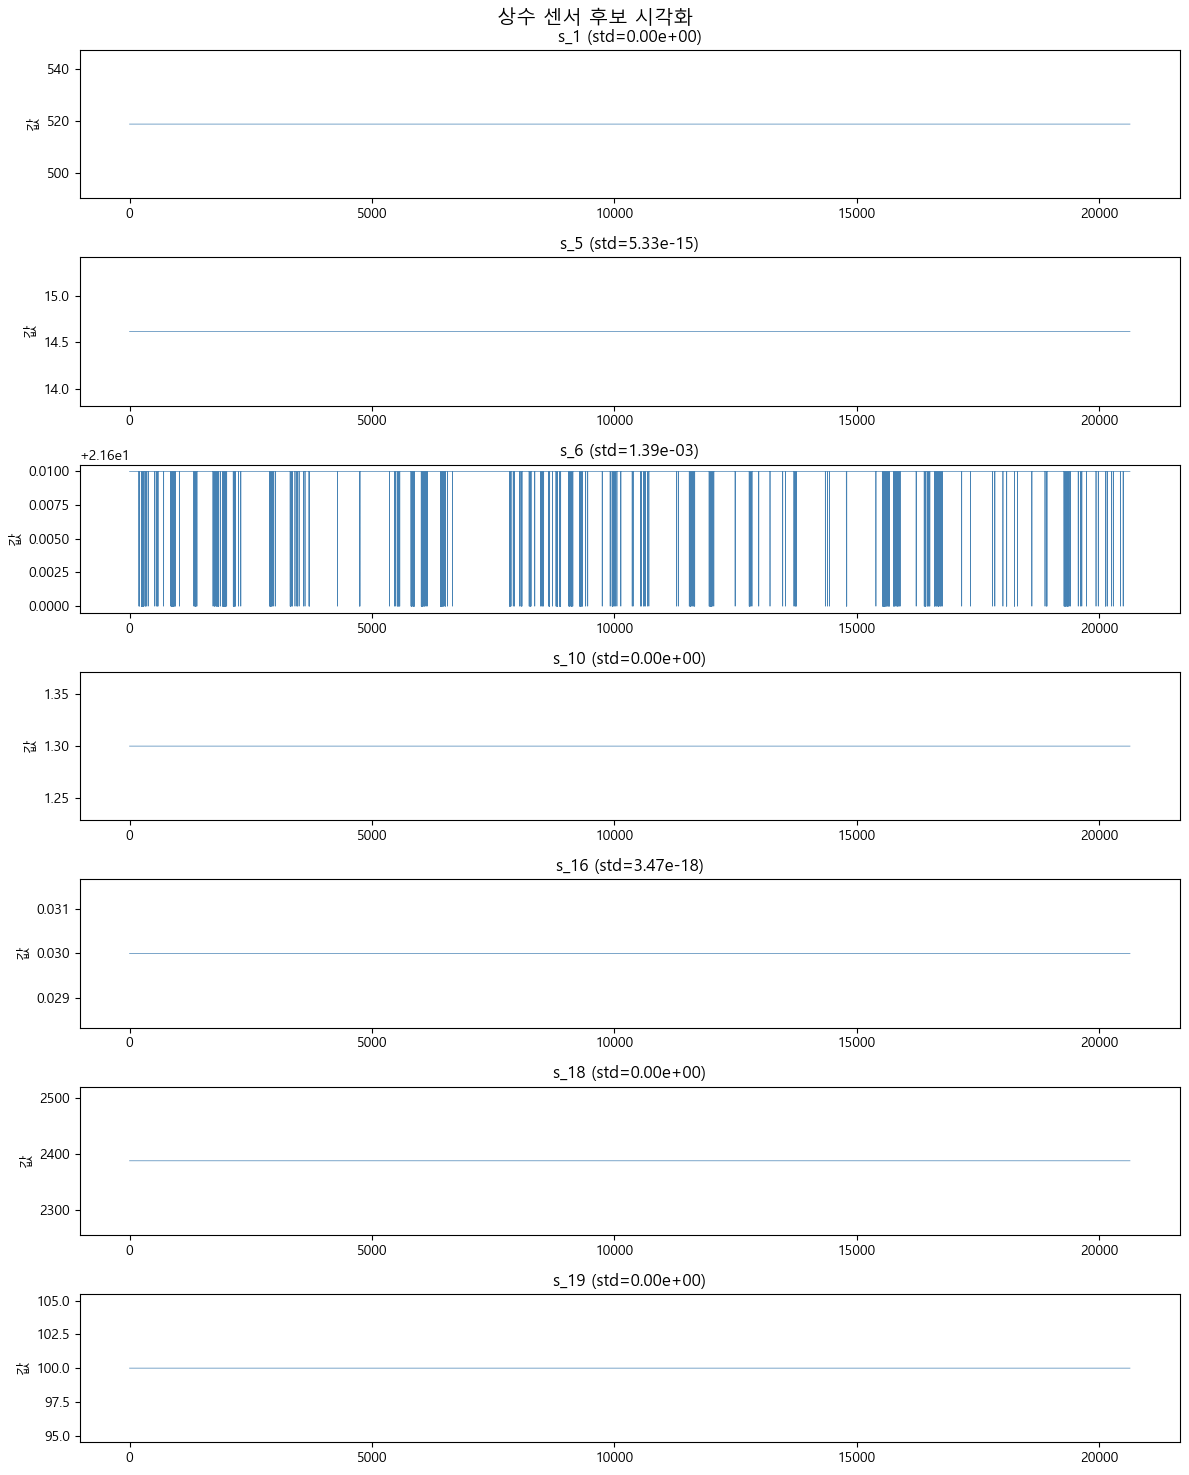

In [12]:
# 상수 센서 후보 시각화
const_candidates = ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']

fig, axes = plt.subplots(len(const_candidates), 1, figsize=(12, 15))

for i, col in enumerate(const_candidates):
    axes[i].plot(train_FD001[col].values, color='steelblue', linewidth=0.5)
    axes[i].set_title(f'{col} (std={train_FD001[col].std():.2e})')
    axes[i].set_ylabel('값')

plt.suptitle('상수 센서 후보 시각화', fontsize=14)
plt.tight_layout()
plt.show()

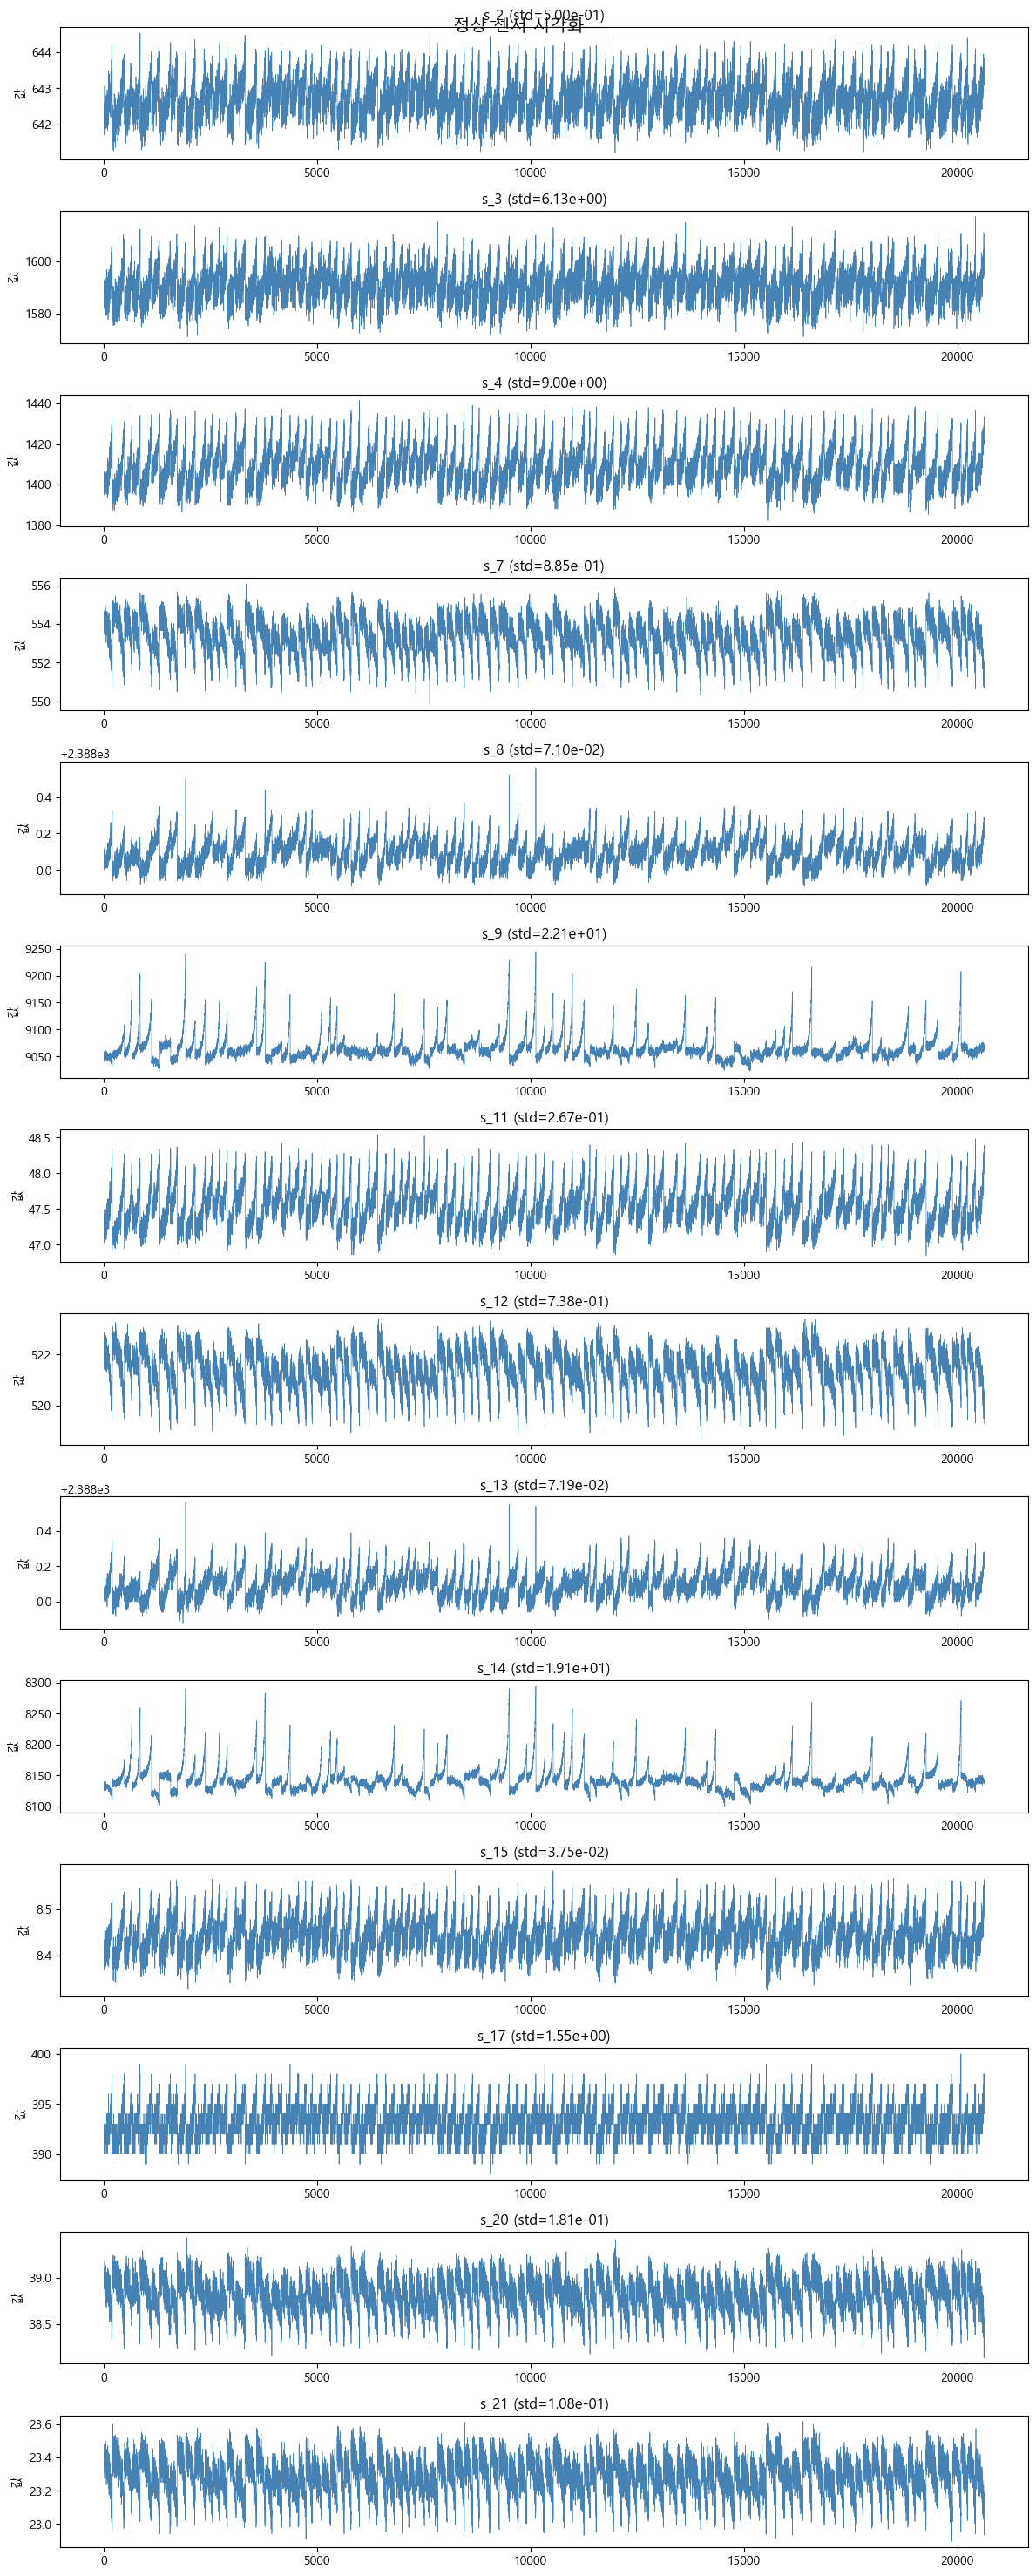

In [13]:
# 정상 센서 시각화
normal_cols = [col for col in sensor_cols if col not in const_candidates]

fig, axes = plt.subplots(len(normal_cols), 1, figsize=(12, 30))

for i, col in enumerate(normal_cols):
    axes[i].plot(train_FD001[col].values, color='steelblue', linewidth=0.5)
    axes[i].set_title(f'{col} (std={train_FD001[col].std():.2e})')
    axes[i].set_ylabel('값')

plt.suptitle('정상 센서 시각화', fontsize=14)
plt.tight_layout()
plt.show()

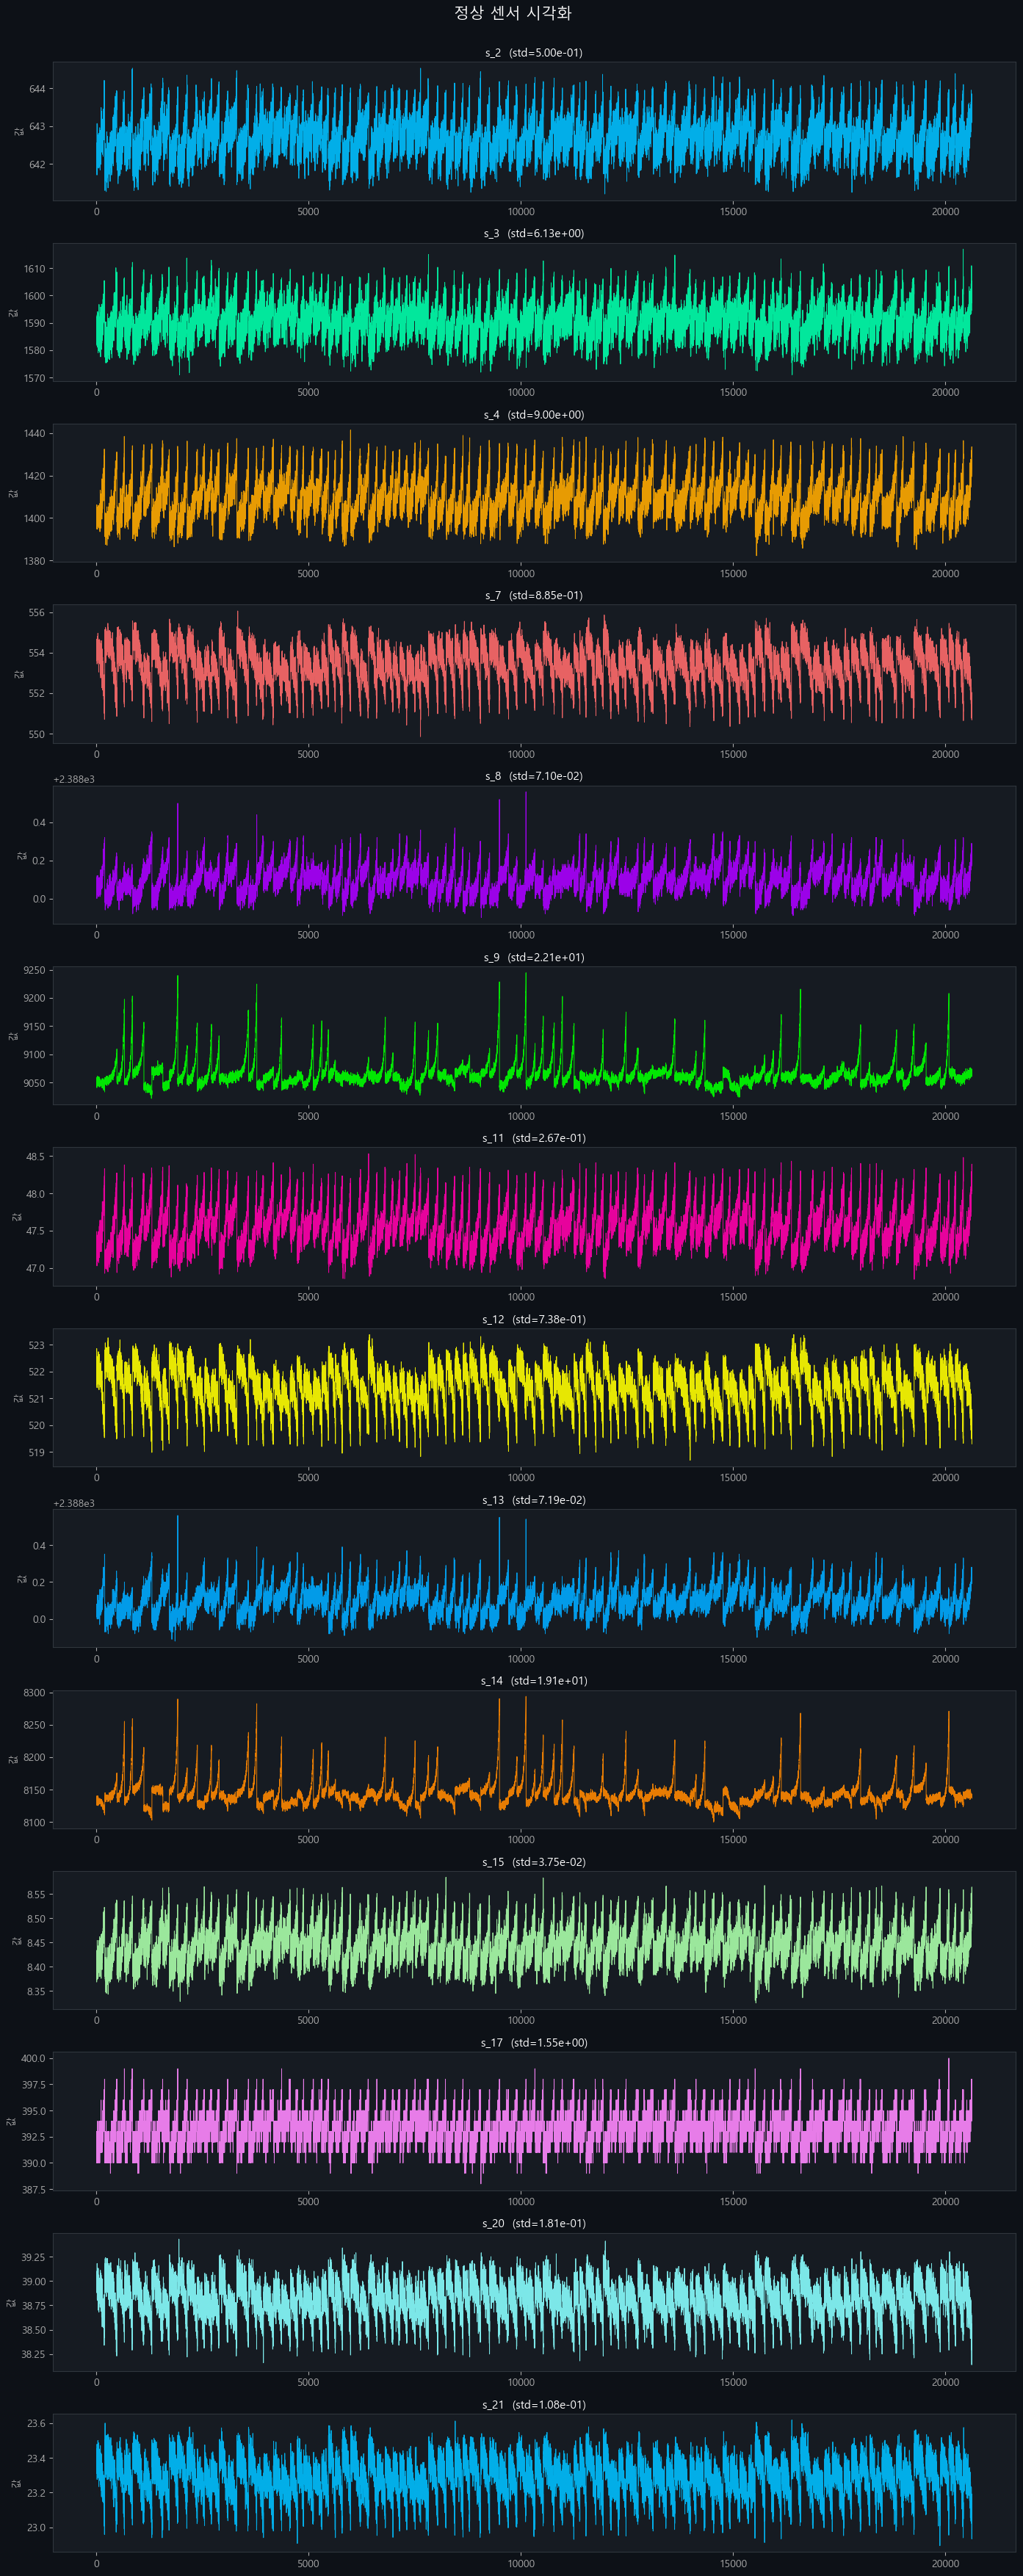

In [15]:
#민준님 스타일대로 예쁘게 그려보기
fig, axes = plt.subplots(len(normal_cols), 1, figsize=(14, 35))
fig.patch.set_facecolor('#0d1117')  # 전체 배경 어둡게

colors = ['#00bfff', '#00ffaa', '#ffaa00', '#ff6b6b', '#aa00ff',
          '#00ff00', '#ff00aa', '#ffff00', '#00aaff', '#ff8800',
          '#aaffaa', '#ff88ff', '#88ffff']

for i, col in enumerate(normal_cols):
    axes[i].set_facecolor('#161b22')  # 그래프 배경
    axes[i].plot(train_FD001[col].values, 
                 color=colors[i % len(colors)], 
                 linewidth=0.7, alpha=0.9)
    axes[i].set_title(f'{col}  (std={train_FD001[col].std():.2e})', 
                      color='white', fontsize=11, pad=6)
    axes[i].set_ylabel('값', color='#aaaaaa', fontsize=9)
    axes[i].tick_params(colors='#aaaaaa')
    for spine in axes[i].spines.values():
        spine.set_edgecolor('#30363d')

plt.suptitle('정상 센서 시각화', fontsize=15, color='white', y=1.001)
plt.tight_layout()
plt.show()

---
### 📊 상수 센서 확인 결과

**상수 센서란?**
> 매 비행마다 값이 변하지 않고 항상 똑같은 센서  
> 엔진 상태 변화를 반영 못하므로 모델 학습에 도움이 안됨 → 제거 대상

| 센서 | std | 판정 |
|------|-----|------|
| s_1 | 0.00e+00 | 완전 상수  |
| s_5 | 5.33e-15 | 사실상 0  |
| s_6 | 1.39e-03 | 거의 상수  |
| s_10 | 0.00e+00 | 완전 상수  |
| s_16 | 3.47e-18 | 사실상 0  |
| s_18 | 0.00e+00 | 완전 상수  |
| s_19 | 0.00e+00 | 완전 상수  |

> 시각화로 직접 확인 → 전부 일직선 → 제거 확정

> ⚠️ s_6은 완전 상수는 아니나 std=0.00139로 매우 작음  
> → 1차 실험에서는 제거 후 성능 비교,  
> 성능 차이 있으면 유지하는 방향으로 재실험 예정
---
### 📊 정상 센서 시각화 해석

**그래프 읽는 법**
- x축: 전체 데이터 행 번호 (0~20631)
- y축: 센서 측정값
- 선이 위아래로 출렁일수록 → 값이 잘 변하는 센서

**코드 핵심 개념 정리**

| 코드 | 의미 |
|------|------|
| `startswith('s_')` | 이름이 s_로 시작하는 컬럼만 선택 |
| 리스트 컴프리헨션 | 한 줄짜리 for문으로 리스트 만들기 |
| `enumerate` | 인덱스(i)와 값(col)을 동시에 꺼내기 |
| `plt.subplots(n, 1)` | n개의 그래프를 세로로 배치 |
| `:.2e` | 소수점 2자리 과학적 표기법으로 표시 |
| `alpha=0.9` | 선 투명도 (1=불투명, 0=투명) |
| `col not in const_candidates` | 상수 후보에 없는 것만 골라내기 |

> 💡 정상 센서들은 전부 위아래로 출렁이는 패턴을 보임  
> → 엔진 상태 변화를 반영하고 있어서 모델 학습에 사용 가능

---
## 5. 상수 센서 제거

### 💡 왜 제거하나?
시각화로 확인 결과 s_1, s_5, s_6, s_10, s_16, s_18, s_19는  
값이 변하지 않아 모델 학습에 도움이 안됨 → 제거

### 🔍 제거 기준
- std < 0.01 → 제거 대상
- s_6은 완전 상수는 아니나 std=0.00139로 매우 작아 1차 실험에서 제거

> ⚠️ 제거 전후 shape 반드시 확인!

In [16]:
# 제거할 센서 목록
drop_cols = ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']

# 제거
train_FD001 = train_FD001.drop(columns=drop_cols)

# 제거 전후 확인
print('제거 후 shape:', train_FD001.shape)
print('남은 센서:', [col for col in train_FD001.columns if col.startswith('s_')])

제거 후 shape: (20631, 19)
남은 센서: ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']


### 📊 제거 결과

| 항목 | 전 | 후 |
|------|----|----|
| 전체 컬럼 수 | 26개 | 19개 |
| 센서 수 | 21개 | 14개 |
| 제거된 센서 | - | s_1, s_5, s_6, s_10, s_16, s_18, s_19 |

> 남은 센서: s_2, s_3, s_4, s_7, s_8, s_9, s_11, s_12, s_13, s_14, s_15, s_17, s_20, s_21

---
## 📋 전처리 진행 현황 (FD001 기준)

### 완료된 단계

| 단계 | 내용 | 결과 |
|------|------|------|
| 1. 데이터 불러오기 | 컬럼명 통일, txt 파일 로드 | shape: (20631, 26) |
| 2. 기본 파악 | shape, info, describe 확인 | 결측값 없음, 엔진 100개 |
| 3. 엔진 수명 분석 | 엔진별 비행 횟수 확인 | 평균 206번, 최대 362번 |
| 4. 상수 센서 확인 | std < 0.01 센서 시각화 확인 | 7개 제거 대상 확인 |
| 5. 상수 센서 제거 | s_1, s_5, s_6, s_10, s_16, s_18, s_19 제거 | shape: (20631, 19) |

### 🔜 앞으로 할 단계

| 단계 | 내용 | 비고 |
|------|------|------|
| 6. RUL Clipping | max_cycle 계산 + CAP=125 적용 | RUL 컬럼은 여기서 생성 |
| 7. 가우시안 필터 | σ=2 고정 후 실험 | 정규화 전에 적용 |
| 8. 정규화 | MinMax 고정 후 실험 | 반드시 마지막에 |
| 9. 슬라이딩 윈도우 | 크기=30 고정 후 실험 | - |
| 10. ML 직전 | setting 컬럼 제거 | FD001만 해당 |

### 📌 결정된 사항
- setting 컬럼 → ML 직전에 제거 (팀원분은 유지)
- RUL 컬럼 → Clipping 단계에서 같이 생성
- s_6 → 1차 실험에서 제거 후 성능 비교 예정

---
## 6. RUL Clipping

### 💡 왜 Clipping이 필요한가?
RUL을 그냥 계산하면 초반 비행에서 RUL이 너무 큽니다.  
예를 들어 수명이 300번인 엔진의 1번째 비행 RUL = 299  

근데 실제로 엔진은 초반엔 정상 상태라서  
센서값이 거의 변하지 않습니다.  
즉 RUL=299나 RUL=125나 센서값이 똑같다는 뜻입니다.

> 💡 모델 입장에서  
> "이 엔진 아직 멀쩡한데 RUL이 299야 125야"를 구분할 근거가 없습니다.  
> 그래서 일정 값 이상은 전부 CAP으로 잘라버립니다.

### 🔍 계산 방법
RUL = min(max_cycle - time_cycles, CAP)

CAP = 125 (1차 실험 고정값)

In [17]:
CAP = 125

# 엔진별 최대 사이클 계산 후 각 행에 붙이기
# transform('max'): groupby().max()와 달리 원래 행 수를 유지하면서
# 각 행에 해당 엔진의 최댓값을 붙여줌 → 별도 merge 불필요
max_cycle = train_FD001.groupby('unit_nr')['time_cycles'].transform('max')

# RUL 계산: 수명 - 현재 사이클
train_FD001['RUL'] = max_cycle - train_FD001['time_cycles']

# CAP 적용: 125 초과는 전부 125로 고정
train_FD001['RUL'] = train_FD001['RUL'].clip(upper=CAP)

# 확인
print('RUL 컬럼 추가 후 shape:', train_FD001.shape)
print('\nRUL 기초 통계:')
print(train_FD001['RUL'].describe())

RUL 컬럼 추가 후 shape: (20631, 20)

RUL 기초 통계:
count    20631.000000
mean        86.829286
std         41.673699
min          0.000000
25%         51.000000
50%        103.000000
75%        125.000000
max        125.000000
Name: RUL, dtype: float64
